## Vectorizing Operations

The first element on our checklist was to examine data types.

If we have downcast all our data, what should we do next?

### What is vectorization?
Vectorization is doing operations on sets of values instead of individual values.

Example of a numpy function that is "vectorized":

In [1]:
import numpy as np

In [2]:
%timeit np.sum(np.arange(100000))

199 μs ± 4.25 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Compare this to a function that is not vectorized:

In [4]:
def sum_test():    
    total = 0
    for i in np.arange(100000):
        total += i
    return total

%timeit sum_test

36.7 ns ± 3.48 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


Orders of magnitude faster.

Often it feels easier to use for loops because they are easier to conceive and write. Taking time to vectorize an operation can help speed up code significantly, however.

Another example of an operation we already vectorized:

To look at crop rotation, we had to assign values to an array based on the values of other arrays.

The non-vectorized version:

In [5]:
y16 = np.random.randint(0,2,size=1000000).reshape(1000,1000)
y17 = np.random.randint(0,2,size=1000000).reshape(1000,1000)

In [6]:
def non_vect():
    rotate = np.zeros([1000,1000])
    for i in range(1000):
        for j in range(1000):
            rotate[i,j] = (1-y16[i,j])*y17[i,j]
    return rotate

%timeit non_vect()

1.02 s ± 53.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


The vectorized version:

In [7]:
%timeit (1-y16)*y17

4.6 ms ± 242 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Which is quite a bit of a speed improvement.

Another useful aspect of vectorization is that `numpy` will __broadcast__ arrays together:

In [8]:
import numpy as np
sample = np.random.normal(loc=[4., 20.], scale=[1., 3.5],
                           size=(10, 2))

In [9]:
sample

array([[ 5.57832644, 19.19854629],
       [ 4.74371361, 19.74889468],
       [ 3.89544577, 19.50315273],
       [ 4.44280326, 20.63549483],
       [ 4.01452289, 21.96495666],
       [ 4.62075557, 14.64686199],
       [ 2.79301668, 15.08142295],
       [ 3.45885645, 17.76250891],
       [ 4.87102198, 21.77831591],
       [ 4.58093129, 20.69288879]])

In [10]:
sample.mean(axis=0)

array([ 4.29993939, 19.10130437])

In [11]:
mu = sample.mean(axis=0)

In [12]:
mu

array([ 4.29993939, 19.10130437])

How could we demean this?

In [13]:
(sample[:,:] - mu).mean(axis=0)

array([-1.02140518e-15,  5.32907052e-16])

Why did this work? These are not compatible arrays!

When an operation is done between two mismatched arrays, `numpy` first checks whether the right most dimension matches. If they match, it broadcasts (essentially repeats) the array so that it becomes the same shape as the other array.

In this case, it found an array that was (10,2) and (,2), so it simply repeated the mean 10 times so that it was (10,2). Then it did an element by element subtraction.

This could be used to standardize arrays:

In [14]:
std = sample.std(axis=0)

In [15]:
((sample -mu)/std).std()

1.0

You can very easily do this with pandas dataframes too:

In [16]:
import pandas as pd
sample_df = pd.DataFrame(sample)

In [17]:
sample_df.mean()

0     4.299939
1    19.101304
dtype: float64

In [18]:
(sample_df-sample_df.mean())/sample_df.std()

,0,1
0,1.623124,0.038097
1,0.563445,0.253707
2,-0.513572,0.157432
3,0.181389,0.601051
4,-0.362384,1.121895
5,0.407329,-1.745119
6,-1.913288,-1.574871
7,-1.067894,-0.524501
8,0.725084,1.048774
9,0.356766,0.623536


### An aside: data stacking and pivoting with pandas
We have not yet mentioned all of the ways to do pivot tables and data transformations in pandas.

Let' start with the "stack" function

In [19]:
import pandas as pd

df = pd.read_csv("panel_example.csv")

df = df.set_index(['i','t'])

Dataframes can use multi-level indices which can be useful:

In [20]:
df_wide = df['value'].unstack(level=0)

df_wide

i,0,1,2,3
t,,,,
0,4.688026,20.763822,13.345220,2.874506
1,5.522693,21.364728,13.759424,17.500661
2,3.794489,16.473118,15.433405,21.603200
3,3.964962,22.906417,7.599836,3.615383
4,2.411890,20.685359,12.815756,12.067565
5,3.411730,23.985350,9.567005,12.347808
6,5.471047,17.449606,13.707837,6.555567
7,2.224358,24.309989,5.037831,7.524997
8,3.014295,19.684198,9.862822,-2.819713


So calling `unstack` will automatically use the outermost index. Setting the level will change this behavior.

In [22]:
df['value'].unstack(level=0)

i,0,1,2,3
t,,,,
0,4.688026,20.763822,13.345220,2.874506
1,5.522693,21.364728,13.759424,17.500661
2,3.794489,16.473118,15.433405,21.603200
3,3.964962,22.906417,7.599836,3.615383
4,2.411890,20.685359,12.815756,12.067565
5,3.411730,23.985350,9.567005,12.347808
6,5.471047,17.449606,13.707837,6.555567
7,2.224358,24.309989,5.037831,7.524997
8,3.014295,19.684198,9.862822,-2.819713


A fancier version of this is the `pivot_table` function, which can handle statistics.

In [23]:
pd.pivot(df.reset_index(), # Reset the index, i and t are columns
         columns="t", # What I want the columns to be
         values='value', # What I want the values to be
         index="i") # What I wand the rows to be

t,0,1,2,3,4,5,6,7,8,9
i,,,,,,,,,,
0,4.688026,5.522693,3.794489,3.964962,2.411890,3.411730,5.471047,2.224358,3.014295,3.628636
1,20.763822,21.364728,16.473118,22.906417,20.685359,23.985350,17.449606,24.309989,19.684198,19.468067
2,13.345220,13.759424,15.433405,7.599836,12.815756,9.567005,13.707837,5.037831,9.862822,17.529517
3,2.874506,17.500661,21.603200,3.615383,12.067565,12.347808,6.555567,7.524997,-2.819713,-12.429077


Cow data example

In [24]:
d

,breed,country_of_origin,sire_code,eval_period,price,birth_date,pta_milk,pta_fat_lb,pta_scs,pta_protein_lb,pta_dpr,id
0,AY,CAN,10092,2000-02,12.0,10/20/1991,1124.0,41.0,3.32,32.0,NaN,AYCAN10092
1,AY,CAN,10094,2000-02,18.0,6/15/1992,1664.0,44.0,2.92,35.0,NaN,AYCAN10094
2,AY,CAN,10181,2000-02,12.0,5/30/1992,939.0,45.0,2.87,27.0,NaN,AYCAN10181
3,AY,CAN,10180,2000-02,12.0,6/25/1992,660.0,30.0,3.28,21.0,NaN,AYCAN10180
4,AY,CAN,10095,2000-02,15.0,10/25/1992,259.0,26.0,3.18,6.0,NaN,AYCAN10095
...,...,...,...,...,...,...,...,...,...,...,...,...
150826,SR,SWE,17830,2020-08,NaN,1/1/1970,1532.0,53.0,2.77,46.0,4.6,SRSWE17830
150827,SR,SWE,17829,2020-08,NaN,1/1/1970,2150.0,95.0,3.08,77.0,1.8,SRSWE17829
150828,SR,SWE,17825,2020-08,NaN,1/1/1970,894.0,42.0,3.35,44.0,3.8,SRSWE17825
150829,WW,NLD,11364,2020-08,NaN,1/1/1970,-1301.0,-6.0,3.06,-14.0,-0.5,WWNLD11364


In [23]:
data_dir="C:/Users/jhtchns2/Box/ACE_592_SAE/Class_Examples/3_Numeric/"
d = pd.read_csv(data_dir + "naab_example.csv")

# Make an id
d['id'] = d['breed'] + d['country_of_origin'] + d['sire_code'].astype(str)

In [25]:
# Look at milk yield by bull and period
pd.pivot_table(d,
               index='id',
               columns=['eval_period'],
               values='pta_milk')

eval_period,2000-02,2000-05,2000-08,2000-11,2001-02,2001-05,2001-08,2001-11,2002-02,2002-05,...,2017-08,2017-12,2018-04,2018-08,2018-12,2019-04,2019-08,2019-12,2020-04,2020-08
id,,,,,,,,,,,,,,,,,,,,,
AY84010863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1054.142857,1054.142857,975.038847,956.241855,954.899273,932.919628
AY8401881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AY8401885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,891.235589,879.487469,768.072290,NaN
AY8401886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1256.993734,1282.056391,1300.070175,1318.867168,1410.502506,1246.028822,1040.828321,1115.233083,1093.371038,840.605119
AY8401887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WWUSA9334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WWUSA9335,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,970.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WWUSA9336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Using an index that applies to more than one cow means we can specify an "aggfunc" (aggregation function):

In [26]:
# A pivot table of averages by breed
breed_avgs = pd.pivot_table(d,                   # dataframe
                            index='eval_period', # period (t) for the row
                            columns=['breed'], # breed for the column
                            values='pta_milk', # describe milk yield
                            aggfunc="mean") # aggregate by taking the average

breed_avgs

breed,AY,BS,GU,HO,JE,MI,MO,MS,NR,RE,SM,SR,WW
eval_period,,,,,,,,,,,,,
2000-02,1078.620000,1314.545455,1296.542857,1563.768177,1268.117647,NaN,NaN,1087.714286,NaN,NaN,NaN,NaN,1413.426667
2000-05,1136.027027,1362.111111,1434.968750,1634.062262,1370.114583,NaN,NaN,1185.714286,NaN,NaN,NaN,NaN,1353.507463
2000-08,1164.090909,1373.444444,1536.958333,1646.885486,1386.071429,NaN,NaN,1161.285714,NaN,NaN,NaN,NaN,652.254545
2000-11,1209.303030,1466.000000,1519.043478,1677.508021,1394.630000,NaN,NaN,1063.142857,NaN,NaN,NaN,NaN,685.795918
2001-02,1211.911765,1466.571429,1617.818182,1714.026560,1439.809524,NaN,NaN,1167.375000,NaN,NaN,NaN,NaN,681.295455
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-04,1508.389523,2286.680058,1585.225705,3251.635882,2217.836529,NaN,8.5,703.710097,1748.428571,991.800000,NaN,1194.785714,245.571429
2019-08,1476.929166,2296.416700,1539.566514,3265.445018,2227.282702,NaN,-39.5,783.097222,1783.428571,961.346154,NaN,1295.428571,-66.000000
2019-12,1467.566768,2324.473739,1525.470566,3296.811459,2297.008547,-1670.0,-6.0,785.478175,1752.625000,1040.260870,-480.0,1278.285714,130.000000


<Axes: xlabel='eval_period'>

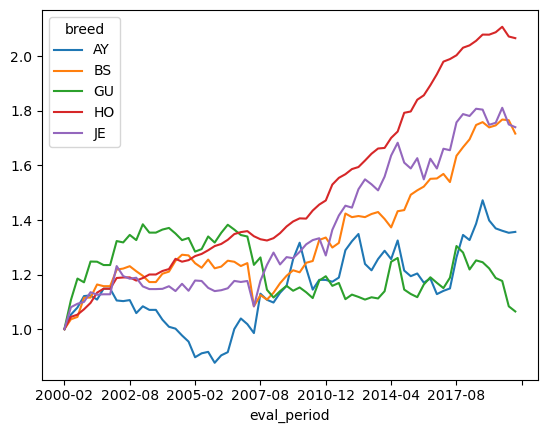

In [42]:
(breed_avgs.iloc[:,:5]/breed_avgs.iloc[0,:5]) .plot()

Most "improvement" in milk yield has happened with "HO" (Holstein) cows.